# Streak Counts Over Time — cadence investigation

Explores the middle-left panel of `crossmatch_summary_panel`:
orbit-class streak counts binned over time.

Key questions:
1. How many streaks total are in that panel?
2. Why do LEO counts increase over time?
3. Why do GEO counts rise then fall (2022–2023 peak)? Is it survey cadence?

Strategy: compare raw streak counts to the number of HETDEX shots taken in
each bin. If GEO *rate per shot* is flat but raw counts peak, the rise-and-fall
is purely cadence (more shots were taken then).  If the rate also peaks, it is
a real signal.

In [1]:
%matplotlib inline
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from astropy.table import Table
from astropy.io import fits

# --- paths ---
REPO_DIR    = os.path.expanduser("~/work/pdr1/claude-tests/satellites/hetdex_sats")
CATALOG     = os.path.join(REPO_DIR, "HETDEX_PDR1_satellites.fits")
INT_CATALOG = os.path.join(REPO_DIR, "intermediate/HETDEX_PDR1_sats.fits")
IFU_INDEX   = os.path.expanduser("~/work/pdr1/ifu-index.fits")

# --- ApJL style (matches crossmatch_figures.ipynb) ---
mpl.rcParams.update({
    "font.family": "serif", "font.size": 8,
    "axes.labelsize": 8, "axes.titlesize": 8,
    "xtick.labelsize": 7, "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "xtick.direction": "in", "ytick.direction": "in",
    "xtick.top": True, "ytick.right": True,
    "xtick.minor.visible": True, "ytick.minor.visible": True,
    "axes.linewidth": 0.7, "lines.linewidth": 1.0,
    "figure.dpi": 120, "savefig.dpi": 200,
})

ORBIT_CLASS_COLORS = {"LEO": "#E64B35", "MEO": "#4DBBD5",
                      "GEO": "#00A087", "HEO": "#3C5488",
                      "Unknown": "#8491B4", "Unidentified": "#999999"}
ORBIT_CLASS_ORDER  = ["LEO", "MEO", "GEO", "HEO", "Unknown"]

MJD_J2000 = 51544.5
def mjd_to_year(mjd):
    return 2000.0 + (np.asarray(mjd, float) - MJD_J2000) / 365.25
def year_to_mjd(year):
    return (np.asarray(year, float) - 2000.0) * 365.25 + MJD_J2000

print("imports OK")

imports OK


In [2]:
# Load the publication catalog (matched streaks only, as in crossmatch_figures.ipynb)
pub = Table.read(CATALOG)

# Apply the same renames as crossmatch_figures.ipynb
pub.rename_columns(
    ["MJDx",        "Class",       "Height",       "Range",    "ginst",      "PA"],
    ["crossing_mjd","orbit_class","sat_height_km","range_km","g_mag_inst","streak_pa_sph_deg"],
)
pub["matched"] = ~np.asarray(pub["NORAD"].mask
                              if hasattr(pub["NORAD"], "mask")
                              else np.zeros(len(pub), bool))

m = pub[pub["matched"]]   # matched rows only — these are what the panel shows

def as_str(col):
    out = []
    for v in np.asarray(col).ravel():
        if isinstance(v, (bytes, np.bytes_)):
            v = v.decode("utf-8", "replace")
        s = str(v).strip()
        out.append(s if s else "Unknown")
    return np.array(out, dtype=object)

oc  = as_str(m["orbit_class"])
mjd = np.asarray(m["crossing_mjd"], float)

print(f"Total streaks in catalog : {len(pub)}")
print(f"Matched (shown in panel) : {len(m)}")
print()
print("Orbit class breakdown:")
for cls in ORBIT_CLASS_ORDER:
    n = int((oc == cls).sum())
    print(f"  {cls:6s}  {n:3d}  ({100*n/len(m):.1f}%)")

Total streaks in catalog : 527
Matched (shown in panel) : 468

Orbit class breakdown:
  LEO     191  (40.8%)
  MEO      64  (13.7%)
  GEO      97  (20.7%)
  HEO     116  (24.8%)
  Unknown    0  (0.0%)


In [3]:
# --- Q1: how many streaks are in each bin of the panel? ---
# Reproduce the panel binning (12 bins, same as plot_orbit_class_counts default)
NBINS = 12
edges = np.linspace(mjd.min(), mjd.max(), NBINS + 1)
centres = 0.5 * (edges[1:] + edges[:-1])

present = [c for c in ORBIT_CLASS_ORDER if (oc == c).sum() > 0]
stacks  = {c: np.histogram(mjd[oc == c], bins=edges)[0] for c in present}
total_per_bin = np.sum(list(stacks.values()), axis=0)

print("Bin totals (matched streaks per bin, 12 bins):")
print(f"{'Bin':>4}  {'Year range':>20}  {'Total':>6}  " +
      "  ".join(f"{c:>5}" for c in present))
for i in range(NBINS):
    yr0, yr1 = mjd_to_year(edges[i]), mjd_to_year(edges[i+1])
    cells = "  ".join(f"{stacks[c][i]:>5}" for c in present)
    print(f"{i+1:>4}  {yr0:.2f} – {yr1:.2f}  {total_per_bin[i]:>6}  {cells}")
print(f"\nGrand total: {total_per_bin.sum()} (should be {len(m)})")

Bin totals (matched streaks per bin, 12 bins):
 Bin            Year range   Total    LEO    MEO    GEO    HEO
   1  2017.88 – 2018.44       7      2      2      1      2
   2  2018.44 – 2019.00      15      5      3      3      4
   3  2019.00 – 2019.55      20      8      7      0      5
   4  2019.55 – 2020.11      23      3      3     12      5
   5  2020.11 – 2020.67      24     10      6      2      6
   6  2020.67 – 2021.23      34      7      5     12     10
   7  2021.23 – 2021.79      38     16      4      6     12
   8  2021.79 – 2022.35      76     25      9     22     20
   9  2022.35 – 2022.90      63     25      1     22     15
  10  2022.90 – 2023.46      46     25      7      4     10
  11  2023.46 – 2024.02      66     28      6     11     21
  12  2024.02 – 2024.58      56     37     11      2      6

Grand total: 468 (should be 468)


In [4]:
# --- Survey cadence: how many unique HETDEX shots per bin? ---
# The ifu-index has one row per IFU-shot combination.
# We need unique shotids to count distinct pointings.
ifu = Table.read(IFU_INDEX)

# shotid encodes YYYYMMDDNNN — unique per pointing.
# MJD of each shot is not directly in the ifu-index, but we can get it from
# the intermediate catalog which has mjd_shot for all 527 detected streaks.
# For the denominator we want ALL shots in the survey, not just ones with streaks.
# Use the ifu-index: get unique shotids, then convert shotid→MJD via the
# intermediate catalog for those shots that have one, or via date parsing.

# Parse MJD from shotid: shotid = YYYYMMDDNNN
# Convert YYYYMMDD to MJD using astropy
from astropy.time import Time

unique_shotids = np.unique(np.asarray(ifu["shotid"], dtype=int))
print(f"Unique shots in ifu-index: {len(unique_shotids):,}")

# Parse dates from shotid
def shotid_to_mjd(shotids):
    shotids = np.asarray(shotids, dtype=int)
    date_part = shotids // 1000          # YYYYMMDD
    year  = date_part // 10000
    month = (date_part % 10000) // 100
    day   = date_part % 100
    iso = [f"{y:04d}-{mo:02d}-{d:02d}" for y, mo, d in zip(year, month, day)]
    return Time(iso, format="iso", scale="utc").mjd

shot_mjd = shotid_to_mjd(unique_shotids)
print(f"Shot MJD range: {shot_mjd.min():.1f} – {shot_mjd.max():.1f}")
print(f"Year range    : {mjd_to_year(shot_mjd.min()):.2f} – {mjd_to_year(shot_mjd.max()):.2f}")

Unique shots in ifu-index: 6,778
Shot MJD range: 57756.0 – 60522.0
Year range    : 2017.01 – 2024.58


In [5]:
# --- Use the same 12-bin edges (from the matched-streak MJD range) ---
# Count shots per bin
shots_per_bin, _ = np.histogram(shot_mjd, bins=edges)

print("Shots per bin (denominator for the rate):")
print(f"{'Bin':>4}  {'Year range':>20}  {'Shots':>6}  {'Streaks':>8}  {'Rate (streaks/shot)':>20}")
for i in range(NBINS):
    yr0, yr1 = mjd_to_year(edges[i]), mjd_to_year(edges[i+1])
    rate = total_per_bin[i] / shots_per_bin[i] if shots_per_bin[i] > 0 else np.nan
    print(f"{i+1:>4}  {yr0:.2f} – {yr1:.2f}  {shots_per_bin[i]:>6}  "
          f"{total_per_bin[i]:>8}  {rate:>20.4f}")
print(f"\nTotal shots in survey (within streak MJD range): {shots_per_bin.sum():,}")
print(f"Total shots in full survey : {len(unique_shotids):,}")

Shots per bin (denominator for the rate):
 Bin            Year range   Shots   Streaks   Rate (streaks/shot)
   1  2017.88 – 2018.44     490         7                0.0143
   2  2018.44 – 2019.00     389        15                0.0386
   3  2019.00 – 2019.55     643        20                0.0311
   4  2019.55 – 2020.11     627        23                0.0367
   5  2020.11 – 2020.67     696        24                0.0345
   6  2020.67 – 2021.23     608        34                0.0559
   7  2021.23 – 2021.79     492        38                0.0772
   8  2021.79 – 2022.35     763        76                0.0996
   9  2022.35 – 2022.90     490        63                0.1286
  10  2022.90 – 2023.46     435        46                0.1057
  11  2023.46 – 2024.02     439        66                0.1503
  12  2024.02 – 2024.58     482        56                0.1162

Total shots in survey (within streak MJD range): 6,554
Total shots in full survey : 6,778


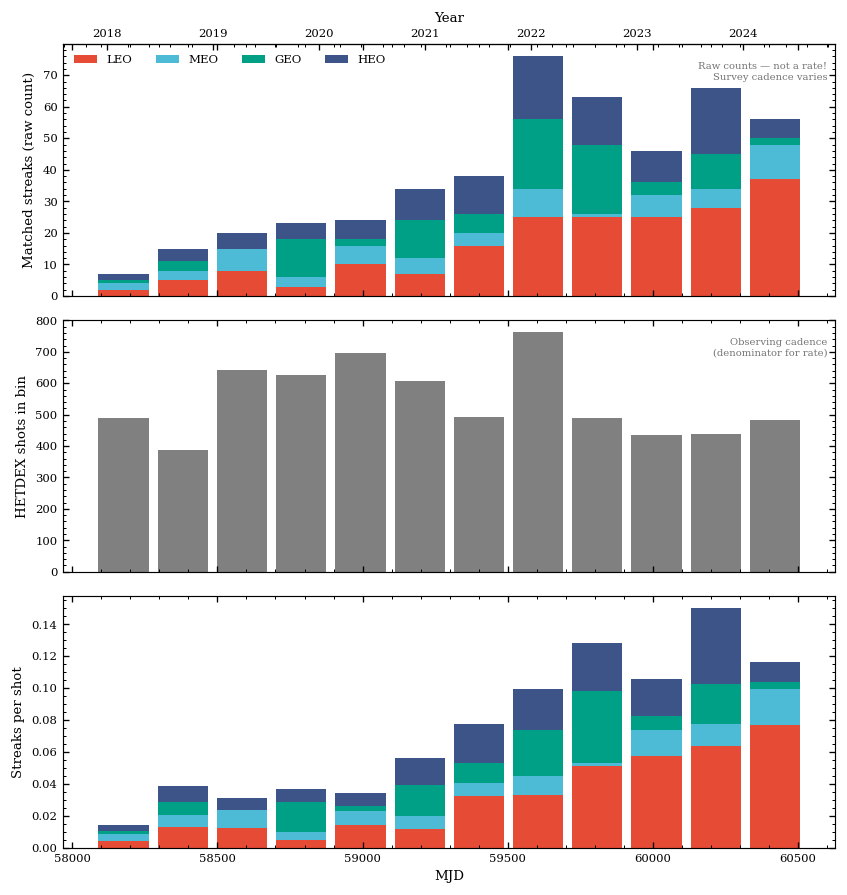

saved figures/streak_rate_vs_cadence.png


In [6]:
# --- Main figure: 3 rows ---
# Row 1: raw streak counts (what the panel shows) — stacked bars by orbit class
# Row 2: survey shots per bin (the denominator / observing cadence)
# Row 3: streak rate per shot per orbit class (the astrophysically meaningful quantity)

fig, axes = plt.subplots(3, 1, figsize=(7.1, 7.5), sharex=True)

bin_w = np.diff(edges)

# ---- Row 1: raw counts (same as the panel) ----
ax = axes[0]
bottom = np.zeros(NBINS)
for c in present:
    ax.bar(centres, stacks[c], width=bin_w * 0.85, bottom=bottom,
           color=ORBIT_CLASS_COLORS.get(c, "#ccc"), label=c, edgecolor="none")
    bottom += stacks[c]
ax.set_ylabel("Matched streaks (raw count)")
ax.legend(frameon=False, ncol=len(present), fontsize=7, loc="upper left")
ax.text(0.99, 0.93, "Raw counts — not a rate!\nSurvey cadence varies",
        transform=ax.transAxes, ha="right", va="top", fontsize=6, color="0.45")

# ---- Row 2: shots per bin (cadence) ----
ax = axes[1]
ax.bar(centres, shots_per_bin, width=bin_w * 0.85, color="0.5", edgecolor="none")
ax.set_ylabel("HETDEX shots in bin")
ax.text(0.99, 0.93, "Observing cadence\n(denominator for rate)",
        transform=ax.transAxes, ha="right", va="top", fontsize=6, color="0.45")

# ---- Row 3: rate per shot ----
ax = axes[2]
bottom = np.zeros(NBINS)
scale = np.where(shots_per_bin > 0, shots_per_bin.astype(float), np.nan)
for c in present:
    rate = stacks[c] / scale
    ax.bar(centres, rate, width=bin_w * 0.85, bottom=bottom,
           color=ORBIT_CLASS_COLORS.get(c, "#ccc"), label=c, edgecolor="none")
    bottom = np.nansum([bottom, rate], axis=0)
ax.set_ylabel("Streaks per shot")
ax.set_xlabel("MJD")

# shared top x-axis with years
sec = axes[0].secondary_xaxis("top", functions=(mjd_to_year, year_to_mjd))
sec.set_xlabel("Year", fontsize=8)
sec.tick_params(labelsize=7)

fig.tight_layout()
plt.savefig(os.path.join(REPO_DIR, "figures/streak_rate_vs_cadence.png"),
            dpi=200, bbox_inches="tight")
plt.show()
print("saved figures/streak_rate_vs_cadence.png")

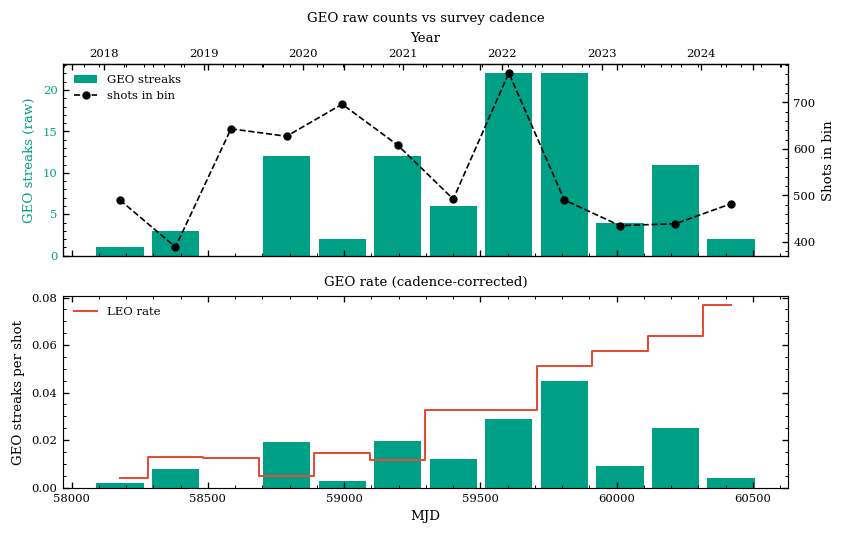

saved figures/geo_rate_investigation.png


In [7]:
# --- Focus on GEO: is the rise-and-fall real or cadence-driven? ---
# Plot GEO raw counts, shot count, and GEO rate per shot in a compact 2-panel figure.

fig, axes = plt.subplots(2, 1, figsize=(7.1, 4.5), sharex=True)

# raw GEO counts
ax = axes[0]
ax.bar(centres, stacks["GEO"], width=bin_w * 0.85,
       color=ORBIT_CLASS_COLORS["GEO"], edgecolor="none", label="GEO streaks")
ax2 = ax.twinx()
ax2.plot(centres, shots_per_bin, "k--o", ms=4, lw=1.0, label="shots in bin")
ax2.set_ylabel("Shots in bin", color="k")
ax2.tick_params(axis="y", labelcolor="k")
ax.set_ylabel("GEO streaks (raw)", color=ORBIT_CLASS_COLORS["GEO"])
ax.tick_params(axis="y", labelcolor=ORBIT_CLASS_COLORS["GEO"])
lines1, labs1 = ax.get_legend_handles_labels()
lines2, labs2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labs1 + labs2, frameon=False, fontsize=7, loc="upper left")
ax.set_title("GEO raw counts vs survey cadence", fontsize=8)

# GEO rate per shot
ax = axes[1]
geo_rate = stacks["GEO"] / scale
ax.bar(centres, geo_rate, width=bin_w * 0.85,
       color=ORBIT_CLASS_COLORS["GEO"], edgecolor="none")
ax.set_ylabel("GEO streaks per shot")
ax.set_xlabel("MJD")
ax.set_title("GEO rate (cadence-corrected)", fontsize=8)

# add LEO rate for comparison
leo_rate = stacks["LEO"] / scale
ax.step(centres, leo_rate, where="mid", color=ORBIT_CLASS_COLORS["LEO"],
        lw=1.2, label="LEO rate")
ax.legend(frameon=False, fontsize=7)

sec = axes[0].secondary_xaxis("top", functions=(mjd_to_year, year_to_mjd))
sec.set_xlabel("Year", fontsize=8)
sec.tick_params(labelsize=7)

fig.tight_layout()
plt.savefig(os.path.join(REPO_DIR, "figures/geo_rate_investigation.png"),
            dpi=200, bbox_inches="tight")
plt.show()
print("saved figures/geo_rate_investigation.png")

In [8]:
# --- Numerical summary: correlation between GEO counts and shot counts ---
# If r is high, the GEO rise-and-fall is mostly cadence.
# If r is low but the rate-per-shot plot is still peaked, it's a real signal.

from scipy import stats

# Only bins with > 0 shots
good = shots_per_bin > 0
r_geo, p_geo = stats.pearsonr(shots_per_bin[good], stacks["GEO"][good])
r_leo, p_leo = stats.pearsonr(shots_per_bin[good], stacks["LEO"][good])

print("Pearson r between shots-per-bin and streak counts:")
print(f"  GEO: r = {r_geo:+.3f}  (p = {p_geo:.3f})")
print(f"  LEO: r = {r_leo:+.3f}  (p = {p_leo:.3f})")
print()
print("GEO rate per shot by bin:")
print(f"{'Bin':>4}  {'Year':>9}  {'Shots':>6}  {'GEO':>5}  {'rate/shot':>10}")
for i in range(NBINS):
    yr = mjd_to_year(centres[i])
    rate = stacks["GEO"][i] / shots_per_bin[i] if shots_per_bin[i] > 0 else np.nan
    print(f"{i+1:>4}  {yr:.2f}  {shots_per_bin[i]:>6}  {stacks['GEO'][i]:>5}  {rate:>10.4f}")
print()
print(f"Mean GEO rate : {np.nanmean(stacks['GEO'][good]/shots_per_bin[good]):.4f} streaks/shot")
print(f"Std  GEO rate : {np.nanstd( stacks['GEO'][good]/shots_per_bin[good]):.4f} streaks/shot")

Pearson r between shots-per-bin and streak counts:
  GEO: r = +0.294  (p = 0.354)
  LEO: r = -0.197  (p = 0.540)

GEO rate per shot by bin:
 Bin       Year   Shots    GEO   rate/shot
   1  2018.16     490      1      0.0020
   2  2018.72     389      3      0.0077
   3  2019.28     643      0      0.0000
   4  2019.83     627     12      0.0191
   5  2020.39     696      2      0.0029
   6  2020.95     608     12      0.0197
   7  2021.51     492      6      0.0122
   8  2022.07     763     22      0.0288
   9  2022.63     490     22      0.0449
  10  2023.18     435      4      0.0092
  11  2023.74     439     11      0.0251
  12  2024.30     482      2      0.0041

Mean GEO rate : 0.0147 streaks/shot
Std  GEO rate : 0.0128 streaks/shot


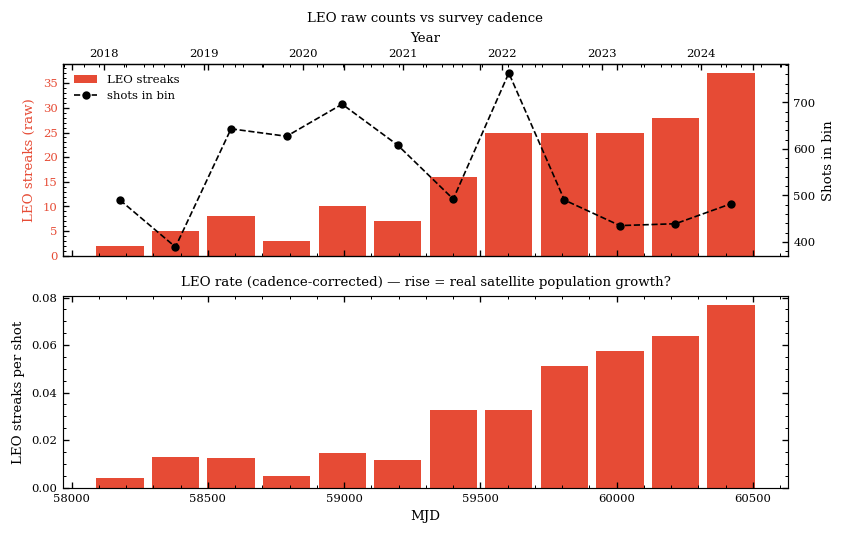

LEO rate per shot by bin:
 Bin       Year   Shots    LEO   rate/shot
   1  2018.16     490      2      0.0041
   2  2018.72     389      5      0.0129
   3  2019.28     643      8      0.0124
   4  2019.83     627      3      0.0048
   5  2020.39     696     10      0.0144
   6  2020.95     608      7      0.0115
   7  2021.51     492     16      0.0325
   8  2022.07     763     25      0.0328
   9  2022.63     490     25      0.0510
  10  2023.18     435     25      0.0575
  11  2023.74     439     28      0.0638
  12  2024.30     482     37      0.0768


In [9]:
# --- Why does LEO increase? Check LEO rate vs time ---
# LEO has grown rapidly since ~2019 (Starlink, OneWeb launches).
# If the rate-per-shot also increases, it is a real astrophysical trend
# (more satellites in orbit), not just more observations.

fig, axes = plt.subplots(2, 1, figsize=(7.1, 4.5), sharex=True)

# Top: LEO raw
ax = axes[0]
ax.bar(centres, stacks["LEO"], width=bin_w * 0.85,
       color=ORBIT_CLASS_COLORS["LEO"], edgecolor="none", label="LEO streaks")
ax2 = ax.twinx()
ax2.plot(centres, shots_per_bin, "k--o", ms=4, lw=1.0, label="shots in bin")
ax2.set_ylabel("Shots in bin", color="k")
ax.set_ylabel("LEO streaks (raw)", color=ORBIT_CLASS_COLORS["LEO"])
ax.tick_params(axis="y", labelcolor=ORBIT_CLASS_COLORS["LEO"])
lines1, labs1 = ax.get_legend_handles_labels()
lines2, labs2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labs1 + labs2, frameon=False, fontsize=7, loc="upper left")
ax.set_title("LEO raw counts vs survey cadence", fontsize=8)

# Bottom: LEO rate — if this still rises, it is real (more satellites exist)
ax = axes[1]
ax.bar(centres, leo_rate, width=bin_w * 0.85,
       color=ORBIT_CLASS_COLORS["LEO"], edgecolor="none")
ax.set_ylabel("LEO streaks per shot")
ax.set_xlabel("MJD")
ax.set_title("LEO rate (cadence-corrected) — rise = real satellite population growth?", fontsize=8)

sec = axes[0].secondary_xaxis("top", functions=(mjd_to_year, year_to_mjd))
sec.set_xlabel("Year", fontsize=8)
sec.tick_params(labelsize=7)

fig.tight_layout()
plt.savefig(os.path.join(REPO_DIR, "figures/leo_rate_investigation.png"),
            dpi=200, bbox_inches="tight")
plt.show()

# Print LEO rate per bin
print("LEO rate per shot by bin:")
print(f"{'Bin':>4}  {'Year':>9}  {'Shots':>6}  {'LEO':>5}  {'rate/shot':>10}")
for i in range(NBINS):
    yr = mjd_to_year(centres[i])
    rate = stacks["LEO"][i] / shots_per_bin[i] if shots_per_bin[i] > 0 else np.nan
    print(f"{i+1:>4}  {yr:.2f}  {shots_per_bin[i]:>6}  {stacks['LEO'][i]:>5}  {rate:>10.4f}")